<a href="https://colab.research.google.com/github/hubcborja/Trabajo_grado_ECIJG/blob/main/UnionFuentesERGM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aplicacion modelo ERGM y VERGM

## Librerias

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import random
import math

pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importación de datos

### Redes de convenios
Obtenidos de https://www.treaties.tax/en/

ICTD (2021). Tax Treaties Explorer [Online database], Brighton: International Centre for Tax and Development (ICTD), retrieved from https://www.treaties.tax

In [ ]:
base_convenios=pd.read_csv('https://raw.githubusercontent.com/hubcborja/Trabajo_grado_ECIJG/refs/heads/main/bases_datos/convenios_tributarios.csv')
# diccionario nombre de las columnas con artículo a nombre del artículo
renombrar_columnas = {
    'Country A': 'pais_origen',
    'Country B': 'pais_destino',
    'Date of signature':'Anio_firma',
    'Effective': 'Anio_vigencia',
    'Source': 'indice_fuente_total',                   # Que tanto beneficia al pais fuente
    'PE': 'indice_establecimiento_permanente',         # Que tanto se le cobran a los establecimientos permanentes
    'WHT Rates': 'indice_tasas_retencion',             # Que tanto tienen de topes las tasas de retención
    'Other': 'indice_otros_derechos',                  # Indice de los otros derechos del convenio
    'UN': 'indice_modelo_onu',                          # Que tanto se parece al modelo ONU (que favorece a los estado en desarrollo)
    '5(3)(a)C': 'duracion_ep_construccion_meses',      # Construction PE length
    '5(3)(a)S': 'actividades_supervision_ep',          # Supervisory activities in PE
    '5(3)(b)': 'duracion_ep_servicios_meses',          # Service PE length
    '5(4)(a)': 'instalaciones_entrega_excluidas_ep',   # Delivery facilities excluded
    '5(4)(b)': 'inventario_entrega_excluido_ep',       # Delivery stock excluded
    '5(5)(b)': 'agente_con_inventario_ep',             # Agent maintaining stock included
    '5(6)': 'corredor_seguros_ep',                     # Insurance broker included
    '5(7)': 'extension_agente_dependiente_ep',         # Dependent agent extension
    '7(1)(b&c)': 'fuerza_atraccion_limitada',          # Limited force of attraction
    '7(3)': 'sin_deduccion_pagos_matriz',              # No deduction payments to head office
    '8(2)': 'impuesto_transporte_maritimo',            # Shared taxing right shipping
    '10(2)(a)Q': 'tasa_retencion_dividendos_calificados', # Qualifying dividend WHT rate
    '10(2)(a)T': 'umbral_participacion_dividendos',    # Threshold for qualified dividends
    '10(2)(b)': 'tasa_retencion_dividendos_portafolio',# Portfolio dividend WHT rate
    '11(2)': 'tasa_retencion_intereses',               # Interest WHT rate
    '11(2)F': 'tasa_retencion_intereses_financieras',  # Financial inst. interest rate
    '12(2)': 'tasa_retencion_regalias',                # Royalties WHT rate
    '12(2)C': 'tasa_retencion_regalias_derechos_autor',# Copyright royalties rate
    '12(2)E': 'tasa_retencion_regalias_equipos',       # Equipment royalties rate
    '12(A)': 'tasa_retencion_servicios_tecnicos',      # Technical service fees rate
    '13(4)': 'ganancia_capital_inmobiliaria',          # Capital gains (land rich)
    '13(5)': 'ganancia_capital_otras_acciones',        # Capital gains (other shares)
    '14': 'servicios_personales_independientes',       # Independent personal services
    '16(2)': 'oficiales_alta_gerencia',                # Top-level managerial officials
    '21(3)': 'impuesto_fuente_otros_ingresos',         # Source taxation other income
    '25B(5)': 'arbitraje_obligatorio_vinculante',      # Mandatory binding arbitration
    '27': 'asistencia_cobro_impuestos',                # Assistance in tax collection
    '29': 'regla_general_anti_abuso'                   # General anti-abuse rule (GAAR)
}

base_convenios.rename(columns=renombrar_columnas, inplace=True)
base_convenios.head()

,pais_origen,pais_destino,Type,Anio_firma,Anio_vigencia,Status,indice_fuente_total,WHTrates,indice_establecimiento_permanente,indice_otros_derechos,indice_modelo_onu,duracion_ep_construccion_meses,actividades_supervision_ep,duracion_ep_servicios_meses,instalaciones_entrega_excluidas_ep,inventario_entrega_excluido_ep,agente_con_inventario_ep,corredor_seguros_ep,extension_agente_dependiente_ep,fuerza_atraccion_limitada,sin_deduccion_pagos_matriz,impuesto_transporte_maritimo,tasa_retencion_dividendos_calificados,umbral_participacion_dividendos,tasa_retencion_dividendos_portafolio,tasa_retencion_intereses,tasa_retencion_intereses_financieras,tasa_retencion_regalias,tasa_retencion_regalias_derechos_autor,tasa_retencion_regalias_equipos,tasa_retencion_servicios_tecnicos,ganancia_capital_inmobiliaria,ganancia_capital_otras_acciones,servicios_personales_independientes,oficiales_alta_gerencia,impuesto_fuente_otros_ingresos,arbitraje_obligatorio_vinculante,asistencia_cobro_impuestos,regla_general_anti_abuso
0,Albania,Israel,Original,2021,2022.00,In Force,0.30,0.31,0.45,0.13,0.26,9.00,YES,12,YES,YES,NO,NO,YES,NO,NO,NO,5,25.00,15,10,10,5,5,5,0,YES,NO,NO,NO,NO,NO,NO,PPT
1,Albania,Turkey,Original,1994,1997.00,In Force,0.19,0.38,0.06,0.13,0.06,12.00,NO,NO,YES,YES,NO,NO,NO,NO,NO,NO,5,25.00,15,10,10,10,10,10,0,NO,NO,YES,NO,NO,NO,NO,NaN
2,Albania,Romania,Original,1994,1995.00,In Force,0.47,0.47,0.58,0.38,0.44,9.00,YES,9,YES,YES,YES,NO,YES,YES,NO,NO,10,25.00,15,10,10,15,15,15,0,NO,NO,YES,NO,YES,NO,NO,NaN
3,Albania,Italy,Original,1994,2000.00,In Force,0.19,0.25,0.19,0.13,0.12,12.00,NO,NO,YES,YES,YES,NO,NO,NO,NO,NO,10,NaN,10,5,5,5,5,5,0,NO,NO,YES,NO,NO,NO,NO,NaN
4,Albania,Russia,Original,1995,1998.00,In Force,0.23,0.38,0.06,0.25,0.12,12.00,NO,NO,YES,YES,NO,NO,NO,NO,NO,NO,10,NaN,10,10,10,10,10,10,0,NO,NO,YES,NO,YES,NO,NO,NaN


In [ ]:
base_convenios.loc[(base_convenios['pais_origen']=='Colombia')|(base_convenios['pais_destino']=='Colombia')]

,pais_origen,pais_destino,Type,Anio_firma,Anio_vigencia,Status,indice_fuente_total,WHTrates,indice_establecimiento_permanente,indice_otros_derechos,indice_modelo_onu,duracion_ep_construccion_meses,actividades_supervision_ep,duracion_ep_servicios_meses,instalaciones_entrega_excluidas_ep,inventario_entrega_excluido_ep,agente_con_inventario_ep,corredor_seguros_ep,extension_agente_dependiente_ep,fuerza_atraccion_limitada,sin_deduccion_pagos_matriz,impuesto_transporte_maritimo,tasa_retencion_dividendos_calificados,umbral_participacion_dividendos,tasa_retencion_dividendos_portafolio,tasa_retencion_intereses,tasa_retencion_intereses_financieras,tasa_retencion_regalias,tasa_retencion_regalias_derechos_autor,tasa_retencion_regalias_equipos,tasa_retencion_servicios_tecnicos,ganancia_capital_inmobiliaria,ganancia_capital_otras_acciones,servicios_personales_independientes,oficiales_alta_gerencia,impuesto_fuente_otros_ingresos,arbitraje_obligatorio_vinculante,asistencia_cobro_impuestos,regla_general_anti_abuso
532,Canada,Colombia,Original,2008,2012.00,In Force,0.45,0.50,0.47,0.38,0.47,6.00,YES,6,YES,YES,NO,YES,NO,NO,NO,NO,5,10.00,15,10,10,10,10,10,10,YES,YES,NO,NO,YES,NO,NO,OTHER
554,Chile,Colombia,Original,2007,2010.00,In Force,0.46,0.42,0.47,0.50,0.53,6.00,YES,6,YES,YES,NO,YES,NO,NO,NO,NO,0,25.00,7,15,5,10,10,10,10,YES,YES,YES,NO,YES,NO,NO,OTHER
647,Colombia,Spain,Original,2005,2008.00,In Force,0.23,0.34,0.22,0.13,0.24,6.00,YES,NO,YES,YES,NO,NO,NO,NO,NO,NO,0,20.00,5,10,0,10,10,10,10,YES,NO,NO,NO,NO,NO,YES,NaN
648,Colombia,Mexico,Original,2009,2013.00,In Force,0.44,0.34,0.47,0.50,0.53,6.00,YES,6,YES,YES,NO,YES,NO,NO,YES,NO,0,NaN,0,10,5,10,10,10,10,YES,YES,NO,NO,YES,NO,YES,LOB
649,Colombia,South Korea,Original,2010,2015.00,In Force,0.40,0.47,0.47,0.25,0.41,6.00,YES,NO,YES,YES,NO,YES,YES,NO,NO,NO,5,20.00,10,10,10,10,10,10,10,YES,YES,NO,NO,NO,NO,YES,PARTIAL
650,Colombia,Portugal,Original,2010,2016.00,In Force,0.53,0.50,0.59,0.50,0.59,6.00,YES,6,YES,YES,NO,YES,YES,NO,NO,NO,10,NaN,10,10,10,10,10,10,10,YES,YES,YES,NO,YES,NO,YES,PPT
651,Colombia,India,Original,2011,2014.00,In Force,0.64,0.44,0.97,0.50,0.76,6.00,YES,6,NO,NO,YES,YES,YES,NO,NO,NO,5,NaN,5,10,10,10,10,10,10,YES,YES,YES,NO,YES,NO,YES,PPT
652,Colombia,Czechia,Original,2012,2016.00,In Force,0.55,0.44,0.97,0.25,0.65,6.00,YES,6,NO,NO,YES,YES,YES,NO,NO,NO,5,25.00,15,10,0,10,10,10,10,NO,YES,NO,NO,YES,NO,NO,PPT
653,Colombia,France,Original,2015,2023.00,In Force,0.30,0.31,0.34,0.25,0.29,6.00,YES,6,YES,YES,NO,NO,NO,NO,NO,NO,5,20.00,15,10,0,10,10,10,0,YES,YES,NO,NO,NO,NO,YES,PPT
654,Colombia,United Kingdom,Original,2016,2020.00,In Force,0.28,0.31,0.09,0.43,0.25,6.00,NO,NO,YES,YES,NO,NO,NO,NO,NaN,NO,5,20.00,15,10,0,10,10,10,0,YES,YES,NO,NO,YES,NO,YES,PPT


### Comtrade

United Nations Statistics Division. (2026). UN Comtrade Database [Data set]. United Nations. https://comtradeplus.un.org/

In [18]:
comtrade=pd.read_csv('https://raw.githubusercontent.com/hubcborja/Trabajo_grado_ECIJG/refs/heads/main/bases_datos/Comtrade_canasta_socios_significativos_2004_2024.csv')
print(comtrade.shape)
comtrade=comtrade.loc[comtrade['reporter_iso_limpio']!=comtrade['partner_iso_limpio']]
print(comtrade.shape)
comtrade.head()

(107624, 8)
(107446, 8)


,period,reporter_iso_limpio,partner_iso_limpio,M,X,peso_comercio_total,balanza_comercial,ln_peso_comercio_total
0,2004,ARE,AFG,82.00,129551474.00,129551556.00,129551392.00,18.68
1,2004,ARE,AGO,0.00,23262625.00,23262625.00,23262625.00,16.96
2,2004,ARE,ALB,0.00,144527.00,144527.00,144527.00,11.88
3,2004,ARE,AND,0.00,24592.00,24592.00,24592.00,10.11
4,2004,ARE,ANT,0.00,63372.00,63372.00,63372.00,11.06


### Gravity

Desde la biblioteca del Gravity

Conte, M., P. Cotterlaz and T. Mayer (2022), "The CEPII Gravity database". CEPII Working Paper N°2022-05, July 2022.

In [15]:
gravity=pd.read_csv('/content/drive/MyDrive/Gravity/Gravity_V202211.csv', low_memory=False)
print(gravity.shape)
gravity=gravity[gravity['year']>=2004]
print(gravity.shape)
print(gravity.columns)
gravity[gravity['iso3_o']=='COL'].head()

(4699296, 87)
(1143072, 87)
Index(['year', 'country_id_o', 'country_id_d', 'iso3_o', 'iso3_d', 'iso3num_o',
       'iso3num_d', 'country_exists_o', 'country_exists_d',
       'gmt_offset_2020_o', 'gmt_offset_2020_d', 'distw_harmonic',
       'distw_arithmetic', 'distw_harmonic_jh', 'distw_arithmetic_jh', 'dist',
       'main_city_source_o', 'main_city_source_d', 'distcap', 'contig',
       'diplo_disagreement', 'scaled_sci_2021', 'comlang_off', 'comlang_ethno',
       'comcol', 'col45', 'legal_old_o', 'legal_old_d', 'legal_new_o',
       'legal_new_d', 'comleg_pretrans', 'comleg_posttrans',
       'transition_legalchange', 'comrelig', 'heg_o', 'heg_d', 'col_dep_ever',
       'col_dep', 'col_dep_end_year', 'col_dep_end_conflict', 'empire',
       'sibling_ever', 'sibling', 'sever_year', 'sib_conflict', 'pop_o',
       'pop_d', 'gdp_o', 'gdp_d', 'gdpcap_o', 'gdpcap_d', 'pop_source_o',
       'pop_source_d', 'gdp_source_o', 'gdp_source_d', 'gdp_ppp_o',
       'gdp_ppp_d', 'gdpcap_ppp_o', 

,year,country_id_o,country_id_d,iso3_o,iso3_d,iso3num_o,iso3num_d,country_exists_o,country_exists_d,gmt_offset_2020_o,gmt_offset_2020_d,distw_harmonic,distw_arithmetic,distw_harmonic_jh,distw_arithmetic_jh,dist,main_city_source_o,main_city_source_d,distcap,contig,diplo_disagreement,scaled_sci_2021,comlang_off,comlang_ethno,comcol,col45,legal_old_o,legal_old_d,legal_new_o,legal_new_d,comleg_pretrans,comleg_posttrans,transition_legalchange,comrelig,heg_o,heg_d,col_dep_ever,col_dep,col_dep_end_year,col_dep_end_conflict,empire,sibling_ever,sibling,sever_year,sib_conflict,pop_o,pop_d,gdp_o,gdp_d,gdpcap_o,gdpcap_d,pop_source_o,pop_source_d,gdp_source_o,gdp_source_d,gdp_ppp_o,gdp_ppp_d,gdpcap_ppp_o,gdpcap_ppp_d,pop_pwt_o,pop_pwt_d,gdp_ppp_pwt_o,gdp_ppp_pwt_d,gatt_o,gatt_d,wto_o,wto_d,eu_o,eu_d,fta_wto,fta_wto_raw,rta_coverage,rta_type,entry_cost_o,entry_cost_d,entry_proc_o,entry_proc_d,entry_time_o,entry_time_d,entry_tp_o,entry_tp_d,tradeflow_comtrade_o,tradeflow_comtrade_d,tradeflow_baci,manuf_tradeflow_baci,tradeflow_imf_o,tradeflow_imf_d
857864,2004,COL,ABW,COL,ABW,170.00,533.00,1,1,-5.00,-4.00,858.00,924.00,NaN,NaN,982.00,UN_WUP_Largest,UN_WUP_Capitals,982.00,0.00,NaN,125638.00,1.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.83,0.00,0.00,0.00,0.00,NaN,NaN,NaN,0.00,0.00,NaN,NaN,42527.62,98.74,117074862.08,2228279.30,2.75,22.57,1.00,1.00,1.00,1.00,330356877.67,NaN,7.73,NaN,42724.16,98.74,308195488.00,4200100.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,25.60,NaN,11.00,NaN,40.00,NaN,51.00,NaN,42926.37,NaN,42926.33,15670.55,42225.78,21764.16
857865,2005,COL,ABW,COL,ABW,170.00,533.00,1,1,-5.00,-4.00,858.00,923.00,NaN,NaN,982.00,UN_WUP_Largest,UN_WUP_Capitals,982.00,0.00,NaN,125638.00,1.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.83,0.00,0.00,0.00,0.00,NaN,NaN,NaN,0.00,0.00,NaN,NaN,43184.03,100.03,146520129.54,2331005.70,3.39,23.30,1.00,1.00,1.00,1.00,357035290.43,NaN,8.25,NaN,43285.63,100.03,330182656.00,4337367.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,24.70,NaN,11.00,NaN,40.00,NaN,51.00,NaN,136176.11,18842.17,146715.92,23577.73,135399.92,24909.53
857866,2006,COL,ABW,COL,ABW,170.00,533.00,1,1,-5.00,-4.00,858.00,923.00,NaN,NaN,982.00,UN_WUP_Largest,UN_WUP_Capitals,982.00,0.00,NaN,125638.00,1.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.83,0.00,0.00,0.00,0.00,NaN,NaN,NaN,0.00,0.00,NaN,NaN,43841.37,100.83,162773598.21,2421474.82,3.71,24.02,1.00,1.00,1.00,1.00,392651515.09,NaN,8.96,NaN,43835.72,100.83,361470656.00,4338022.50,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,19.10,NaN,12.00,NaN,41.00,NaN,53.00,NaN,228903.40,NaN,228903.26,9769.30,223195.52,25230.64
857867,2007,COL,ABW,COL,ABW,170.00,533.00,1,1,-5.00,-4.00,858.00,923.00,NaN,NaN,982.00,UN_WUP_Largest,UN_WUP_Capitals,982.00,0.00,NaN,125638.00,1.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.83,0.00,0.00,0.00,0.00,NaN,NaN,NaN,0.00,0.00,NaN,NaN,44498.39,101.22,207520153.60,2623726.34,4.66,25.92,1.00,1.00,1.00,1.00,430917812.05,NaN,9.71,NaN,44374.57,101.22,397824576.00,4531907.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,18.60,NaN,11.00,NaN,40.00,NaN,51.00,NaN,14705.35,NaN,14702.35,13908.50,14337.07,33326.19
857868,2008,COL,ABW,COL,ABW,170.00,533.00,1,1,-5.00,-4.00,858.00,923.00,NaN,NaN,982.00,UN_WUP_Largest,UN_WUP_Capitals,982.00,0.00,NaN,125638.00,1.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.83,0.00,0.00,0.00,0.00,NaN,NaN,NaN,0.00,0.00,NaN,NaN,45153.04,101.34,244056735.74,2791960.83,5.41,27.55,1.00,1.00,1.00,1.00,454954372.41,NaN,10.13,NaN,44901.54,101.35,431743744.00,4597615.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,14.90,NaN,9.00,NaN,34.00,NaN,43.00,NaN,23665.82,NaN,23661.33,17222.83,23665.81,38610.54


In [16]:
# Base de indices de los paises obtenida desde la biblioteca del Gravity
countries=pd.read_csv('/content/drive/MyDrive/Gravity/Countries_V202211.csv')
print(countries.columns)
countries=countries[['iso3', 'country']]
otros=pd.DataFrame({'iso3':['GGY','IMN','JEY','XKK'],'country':['Guernsey','Isle of Man','Jersey','Kosovo']})
countries=pd.concat([countries, otros], ignore_index=True)
countries.head()

Index(['country_id', 'iso3', 'iso3num', 'country', 'countrylong', 'first_year',
       'last_year', 'countrygroup_iso3', 'countrygroup_iso3num', 'iso2',
       'heg_iso3_2020', 'heg_iso3num_2020'],
      dtype='object')


,iso3,country
0,AFG,Afghanistan
1,ALB,Albania
2,DZA,Algeria
3,ASM,American Samoa
4,AND,Andorra


### Datos del banco mundial

In [17]:
bancomundial=pd.read_csv('https://raw.githubusercontent.com/hubcborja/Trabajo_grado_ECIJG/refs/heads/main/bases_datos/Data_BancoMundial.csv')
print(bancomundial.shape)
bancomundial=bancomundial.loc[0:4773]
bancomundial['Time']=bancomundial['Time'].astype('int64')
bancomundial=bancomundial.loc[(bancomundial['Time']<=2024)&(bancomundial['Time']>=2004)]
bancomundial.replace(['..'], np.nan, inplace=True)
bancomundial=bancomundial.rename(columns={'Time':'year',
                                          'Country Name':'pais',
                                          'Country Code':'iso3',
                                          'GNI per capita, Atlas method (current US$) [NY.GNP.PCAP.CD]':'INB_per_capita_corrientes',
                                          'Population, total [SP.POP.TOTL]':'poblacion',
                                          'Tax revenue (% of GDP) [GC.TAX.TOTL.GD.ZS]':'recaudo_impuestos_porc_PIB',
                                          'Trade (% of GDP) [NE.TRD.GNFS.ZS]':'comercio_porc_PIB',
                                          'Oil rents (% of GDP) [NY.GDP.PETR.RT.ZS]':'rentas_petroletas_porc_PIB',
                                          'Trade in services (% of GDP) [BG.GSR.NFSV.GD.ZS]':'comercio_servicios_porc_PIB',
                                          'Military expenditure (% of GDP) [MS.MIL.XPND.GD.ZS]':'gasto_militar_porc_PIB',
                                          'Foreign direct investment, net inflows (% of GDP) [BX.KLT.DINV.WD.GD.ZS]':'FDI_ingreso_neto_porc_PIB',
                                          'Foreign direct investment, net outflows (% of GDP) [BM.KLT.DINV.WD.GD.ZS]':'FDI_egreso_neto_porc_PIB',
                                          'Taxes on international trade (% of revenue) [GC.TAX.INTT.RV.ZS]':'impuestos_comex_porc_recaudo',
                                          'Taxes on goods and services (% of revenue) [GC.TAX.GSRV.RV.ZS]':'impuestos_bienes_servicios_porc_recaudo',
                                          'GDP per capita, PPP (constant 2021 international $) [NY.GDP.PCAP.PP.KD]':'pib_ppc',
                                          'GDP per capita (constant 2015 US$) [NY.GDP.PCAP.KD]':'pib_per_capita_dolares_constantes',
                                          'GDP, PPP (constant 2021 international $) [NY.GDP.MKTP.PP.KD]':'pib_ppp_dolares_constantes',
                                          'GDP (constant 2015 US$) [NY.GDP.MKTP.KD]':'pib_dolares_constantes'})
bancomundial.head()

(4779, 19)


,year,Time Code,pais,iso3,INB_per_capita_corrientes,poblacion,recaudo_impuestos_porc_PIB,comercio_porc_PIB,rentas_petroletas_porc_PIB,comercio_servicios_porc_PIB,gasto_militar_porc_PIB,FDI_ingreso_neto_porc_PIB,FDI_egreso_neto_porc_PIB,impuestos_comex_porc_recaudo,impuestos_bienes_servicios_porc_recaudo,pib_ppc,pib_per_capita_dolares_constantes,pib_ppp_dolares_constantes,pib_dolares_constantes
0,2004,YR2004,Afghanistan,AFG,210,23560654,NaN,NaN,0.0256051597697051,NaN,2.43125378739118,3.577104200584,-0.0133973940096779,NaN,NaN,1776.91820712187,338.637273888197,41865355064.2988,7978515641.58304
1,2004,YR2004,Albania,ALB,2170,3026939,17.4267041665946,65.0379383187697,0.793153163005221,29.1036629545616,1.38115794211088,4.60782278585291,0.183671566665206,7.56435479675994,48.696259510829,8483.29399553028,2567.29763687121,25678413443.5364,7771053341.65332
2,2004,YR2004,Algeria,DZA,2440,32628286,NaN,61.3579975707176,22.1269733272223,NaN,3.04875701211848,0.962586875552012,0.267043825651592,NaN,NaN,13226.7650481165,4066.28204806495,431566672844.747,132675813620.929
3,2004,YR2004,American Samoa,ASM,NaN,56818,NaN,202.357563850688,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13291.5356626851,NaN,755198473.282443
4,2004,YR2004,Andorra,AND,NaN,74325,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64353.4858113531,40054.3399679173,4783072832.92882,2977038818.11546


## Union y limpieza Bases de datos

In [19]:
# Convenios con nombre de los paises para luego unirla con gravity
nom_paises_nomatch={'DR Congo':'Congo, Democratic Rep. of the',
'Republic of the Congo':'Congo, Rep. of the',
'Curaçao':'Curacao',
'Czechia':'Czech Republic',
'Ivory Coast':'Cote d\'Ivoire',
'Macau':'Macao',
'United States':'United States of America',
'São Tomé and Príncipe':'Sao Tome and Principe'}
base_convenios['pais_origen'] = base_convenios['pais_origen'].replace(nom_paises_nomatch)
base_convenios['pais_destino'] = base_convenios['pais_destino'].replace(nom_paises_nomatch)
base_convenios_nombres=base_convenios.merge(countries, left_on='pais_origen', right_on='country', how='left')
base_convenios_nombres=base_convenios_nombres.merge(countries, left_on='pais_destino', right_on='country', how='left')
base_convenios_nombres.drop(columns=['country_x', 'country_y'], inplace=True)
base_convenios_nombres=base_convenios_nombres.rename(columns={'iso3_x':'iso3_origen', 'iso3_y':'iso3_destino'})
base_convenios_nombres=base_convenios_nombres[['iso3_origen', 'iso3_destino', 'pais_origen', 'pais_destino', 'Anio_firma',
                                               'indice_fuente_total', 'Status', 'Type']]
convenios_colombia_faltantes=pd.DataFrame({'iso3_origen':['COL', 'COL', 'COL', 'COL', 'COL', 'COL', 'COL', 'COL'],
                                           'iso3_destino':['ARE', 'URY', 'NLD', 'BRA', 'PER', 'LUX', 'ECU', 'BOL'],
                                           'pais_origen':['Colombia', 'Colombia', 'Colombia', 'Colombia', 'Colombia', 'Colombia', 'Colombia', 'Colombia'],
                                           'pais_destino':['United Arab Emirates', 'Uruguay', 'Netherlands', 'Brazil', 'Peru', 'Luxembourg', 'Ecuador', 'Bolivia'],
                                           'Anio_firma':[2017,2021, 2022, 2022, 2017, 2024, 2004, 2004],
                                           'indice_fuente_total':[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
                                           'Status':['Not In Force','Not In Force', 'Not In Force', 'Not In Force', 'In Force', 'Not In Force', 'In Force', 'In Force'],
                                           'Type':['Original', 'Original', 'Original', 'Original', 'Amended by MLI', 'Original', 'Amended by protocol', 'Amended by protocol']})
base_convenios_nombres=pd.concat([base_convenios_nombres,convenios_colombia_faltantes])
base_convenios_nombres['iso3_par']=base_convenios_nombres.apply(lambda row: tuple(sorted((row['iso3_origen'], row['iso3_destino']))), axis=1)
base_convenios_nombres.head()


,iso3_origen,iso3_destino,pais_origen,pais_destino,Anio_firma,indice_fuente_total,Status,Type,iso3_par
0,ALB,ISR,Albania,Israel,2021,0.30,In Force,Original,"(ALB, ISR)"
1,ALB,TUR,Albania,Turkey,1994,0.19,In Force,Original,"(ALB, TUR)"
2,ALB,ROU,Albania,Romania,1994,0.47,In Force,Original,"(ALB, ROU)"
3,ALB,ITA,Albania,Italy,1994,0.19,In Force,Original,"(ALB, ITA)"
4,ALB,RUS,Albania,Russia,1995,0.23,In Force,Original,"(ALB, RUS)"


In [20]:
base_convenios_nombres.loc[(base_convenios_nombres['iso3_origen']=='COL')&(base_convenios_nombres['iso3_destino']=='ITA')].head()

,iso3_origen,iso3_destino,pais_origen,pais_destino,Anio_firma,indice_fuente_total,Status,Type,iso3_par
655,COL,ITA,Colombia,Italy,2018,0.45,In Force,Original,"(COL, ITA)"


In [21]:
anio_formacion_tratado = base_convenios_nombres.groupby(['iso3_par', 'Status', 'Type', 'indice_fuente_total'])['Anio_firma'].min().reset_index()
anio_formacion_tratado.rename(columns={'Anio_firma': 'min_Anio_firma'}, inplace=True)
anio_formacion_tratado.head()

,iso3_par,Status,Type,indice_fuente_total,min_Anio_firma
0,"(AGO, ARE)",In Force,Original,0.50,2018
1,"(AGO, PRT)",In Force,Original,0.63,2018
2,"(ALB, ARE)",In Force,Amended by MLI,0.38,2019
3,"(ALB, AUT)",In Force,Amended by MLI,0.23,2019
4,"(ALB, BEL)",In Force,Amended by MLI,0.41,2019


In [22]:
gravity['iso3_par'] = gravity.apply(lambda row: tuple(sorted((row['iso3_o'], row['iso3_d']))), axis=1)
gravity_convenios = gravity.merge(anio_formacion_tratado,on='iso3_par',how='left')
gravity_convenios['CDT_vigente'] = np.where(gravity_convenios['year'] >= gravity_convenios['min_Anio_firma'], 1, 0)
gravity_convenios['CDT_vigente'] = gravity_convenios['CDT_vigente'].fillna(0)
print(gravity_convenios.shape)
gravity_convenios.loc[(gravity_convenios['iso3_o']=='COL')&(gravity_convenios['iso3_d']=='ESP')]

(1143108, 93)


,year,country_id_o,country_id_d,iso3_o,iso3_d,iso3num_o,iso3num_d,country_exists_o,country_exists_d,gmt_offset_2020_o,gmt_offset_2020_d,distw_harmonic,distw_arithmetic,distw_harmonic_jh,distw_arithmetic_jh,dist,main_city_source_o,main_city_source_d,distcap,contig,diplo_disagreement,scaled_sci_2021,comlang_off,comlang_ethno,comcol,col45,legal_old_o,legal_old_d,legal_new_o,legal_new_d,comleg_pretrans,comleg_posttrans,transition_legalchange,comrelig,heg_o,heg_d,col_dep_ever,col_dep,col_dep_end_year,col_dep_end_conflict,empire,sibling_ever,sibling,sever_year,sib_conflict,pop_o,pop_d,gdp_o,gdp_d,gdpcap_o,gdpcap_d,pop_source_o,pop_source_d,gdp_source_o,gdp_source_d,gdp_ppp_o,gdp_ppp_d,gdpcap_ppp_o,gdpcap_ppp_d,pop_pwt_o,pop_pwt_d,gdp_ppp_pwt_o,gdp_ppp_pwt_d,gatt_o,gatt_d,wto_o,wto_d,eu_o,eu_d,fta_wto,fta_wto_raw,rta_coverage,rta_type,entry_cost_o,entry_cost_d,entry_proc_o,entry_proc_d,entry_time_o,entry_time_d,entry_tp_o,entry_tp_d,tradeflow_comtrade_o,tradeflow_comtrade_d,tradeflow_baci,manuf_tradeflow_baci,tradeflow_imf_o,tradeflow_imf_d,iso3_par,Status,Type,indice_fuente_total,min_Anio_firma,CDT_vigente
209898,2004,COL,ESP,COL,ESP,170.00,724.00,1,1,-5.00,1.00,8112.00,8133.00,7993.00,8016.00,8022.00,UN_WUP_Largest,UN_WUP_Largest,8022.00,0.00,1.45,22668.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.94,0.00,1.00,1.00,0.00,1810.00,0.00,NaN,0.00,0.00,NaN,NaN,42527.62,42921.89,117074862.08,1069601980.42,2.75,24.92,1.00,1.00,1.00,1.00,330356877.67,1124492854.27,7.73,26.20,42724.16,43351.67,308195488.00,1238375808.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,NaN,NaN,25.60,17.00,11.00,10.00,40.00,137.00,51.00,147.00,211923.30,289427.94,239229.01,167114.89,208243.08,288371.22,"(COL, ESP)",In Force,Original,0.23,2005.00,0
209899,2005,COL,ESP,COL,ESP,170.00,724.00,1,1,-5.00,1.00,8114.00,8135.00,7993.00,8015.00,8022.00,UN_WUP_Largest,UN_WUP_Largest,8022.00,0.00,1.44,22668.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.94,0.00,1.00,1.00,0.00,1810.00,0.00,NaN,0.00,0.00,NaN,NaN,43184.03,43653.16,146520129.54,1157247664.13,3.39,26.51,1.00,1.00,1.00,1.00,357035290.43,1209299968.29,8.25,27.70,43285.63,44042.63,330182656.00,1344368384.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,NaN,NaN,24.70,16.50,11.00,10.00,40.00,70.00,51.00,80.00,348585.31,436332.17,402089.42,226283.42,342314.97,425184.41,"(COL, ESP)",In Force,Original,0.23,2005.00,1
209900,2006,COL,ESP,COL,ESP,170.00,724.00,1,1,-5.00,1.00,8114.00,8135.00,8010.00,8033.00,8022.00,UN_WUP_Largest,UN_WUP_Largest,8022.00,0.00,1.31,22668.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.94,0.00,1.00,1.00,0.00,1810.00,0.00,NaN,0.00,0.00,NaN,NaN,43841.37,44397.32,162773598.21,1264486711.30,3.71,28.48,1.00,1.00,1.00,1.00,392651515.09,1368901238.29,8.96,30.83,43835.72,44725.53,361470656.00,1473472896.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,NaN,NaN,19.10,16.20,12.00,10.00,41.00,60.00,53.00,70.00,515692.67,653728.84,528764.77,297318.69,501483.03,642020.44,"(COL, ESP)",In Force,Original,0.23,2005.00,1
209901,2007,COL,ESP,COL,ESP,170.00,724.00,1,1,-5.00,1.00,8114.00,8135.00,8002.00,8024.00,8022.00,UN_WUP_Largest,UN_WUP_Largest,8022.00,0.00,1.12,22668.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.94,0.00,1.00,1.00,0.00,1810.00,0.00,NaN,0.00,0.00,NaN,NaN,44498.39,45226.80,207520153.60,1479265746.94,4.66,32.71,1.00,1.00,1.00,1.00,430917812.05,1473681698.81,9.71,32.58,44374.57,45393.86,397824576.00,1576838400.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,NaN,NaN,18.60,15.10,11.00,10.00,40.00,60.00,51.00,70.00,581126.36,688163.68,603469.72,377637.69,569513.44,679117.88,"(COL, ESP)",In Force,Original,0.23,2005.00,1
209902,2008,COL,ESP,COL,ESP,170.00,724.00,1,1,-5.00,1.00,8114.00,8135.00,8001.00,8024.00,8022.00,UN_WUP_Largest,UN_WUP_Largest,8022.00,0.00,1.12,22668.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.94,0.00,1.00,1.00,0.00,1810.00,0.00,NaN,0.00,0.00,NaN,NaN,45153.04,45954.11,244056735.74,1635049537.54,5.41,35.58,1.00,1.00,1.00,1.00,454954372.41,15

In [23]:
# Gravity, convenios y comtrade
comtrade=comtrade.rename(columns={'period':'year', 'reporter_iso_limpio':'iso3_o', 'partner_iso_limpio':'iso3_d'})
gravconv_comtrade=comtrade.merge(gravity_convenios, how='left', on=['year', 'iso3_o', 'iso3_d'])
gravconv_comtrade = gravconv_comtrade.sort_values(by=['iso3_o', 'iso3_d', 'year'])
gravconv_comtrade = gravconv_comtrade.groupby(['iso3_o', 'iso3_d']).ffill()
gravconv_comtrade=gravconv_comtrade.rename(columns={'country_id_o':'iso3_o', 'country_id_d':'iso3_d'})
print(gravconv_comtrade.shape)
gravconv_comtrade.loc[(gravconv_comtrade['iso3_o']=='COL')&(gravconv_comtrade['iso3_d']=='ESP')]

(115340, 96)


,year,M,X,peso_comercio_total,balanza_comercial,ln_peso_comercio_total,iso3_o,iso3_d,iso3num_o,iso3num_d,country_exists_o,country_exists_d,gmt_offset_2020_o,gmt_offset_2020_d,distw_harmonic,distw_arithmetic,distw_harmonic_jh,distw_arithmetic_jh,dist,main_city_source_o,main_city_source_d,distcap,contig,diplo_disagreement,scaled_sci_2021,comlang_off,comlang_ethno,comcol,col45,legal_old_o,legal_old_d,legal_new_o,legal_new_d,comleg_pretrans,comleg_posttrans,transition_legalchange,comrelig,heg_o,heg_d,col_dep_ever,col_dep,col_dep_end_year,col_dep_end_conflict,empire,sibling_ever,sibling,sever_year,sib_conflict,pop_o,pop_d,gdp_o,gdp_d,gdpcap_o,gdpcap_d,pop_source_o,pop_source_d,gdp_source_o,gdp_source_d,gdp_ppp_o,gdp_ppp_d,gdpcap_ppp_o,gdpcap_ppp_d,pop_pwt_o,pop_pwt_d,gdp_ppp_pwt_o,gdp_ppp_pwt_d,gatt_o,gatt_d,wto_o,wto_d,eu_o,eu_d,fta_wto,fta_wto_raw,rta_coverage,rta_type,entry_cost_o,entry_cost_d,entry_proc_o,entry_proc_d,entry_time_o,entry_time_d,entry_tp_o,entry_tp_d,tradeflow_comtrade_o,tradeflow_comtrade_d,tradeflow_baci,manuf_tradeflow_baci,tradeflow_imf_o,tradeflow_imf_d,iso3_par,Status,Type,indice_fuente_total,min_Anio_firma,CDT_vigente
1472,2004,34538536.00,58729893.00,93268429.00,24191357.00,18.35,COL,ESP,170.00,724.00,1.00,1.00,-5.00,1.00,8112.00,8133.00,7993.00,8016.00,8022.00,UN_WUP_Largest,UN_WUP_Largest,8022.00,0.00,1.45,22668.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.94,0.00,1.00,1.00,0.00,1810.00,0.00,NaN,0.00,0.00,NaN,NaN,42527.62,42921.89,117074862.08,1069601980.42,2.75,24.92,1.00,1.00,1.00,1.00,330356877.67,1124492854.27,7.73,26.20,42724.16,43351.67,308195488.00,1238375808.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,NaN,NaN,25.60,17.00,11.00,10.00,40.00,137.00,51.00,147.00,211923.30,289427.94,239229.01,167114.89,208243.08,288371.22,"(COL, ESP)",In Force,Original,0.23,2005.00,0.00
6741,2005,47042202.00,137274091.00,184316293.00,90231889.00,19.03,COL,ESP,170.00,724.00,1.00,1.00,-5.00,1.00,8114.00,8135.00,7993.00,8015.00,8022.00,UN_WUP_Largest,UN_WUP_Largest,8022.00,0.00,1.44,22668.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.94,0.00,1.00,1.00,0.00,1810.00,0.00,NaN,0.00,0.00,NaN,NaN,43184.03,43653.16,146520129.54,1157247664.13,3.39,26.51,1.00,1.00,1.00,1.00,357035290.43,1209299968.29,8.25,27.70,43285.63,44042.63,330182656.00,1344368384.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,NaN,NaN,24.70,16.50,11.00,10.00,40.00,70.00,51.00,80.00,348585.31,436332.17,402089.42,226283.42,342314.97,425184.41,"(COL, ESP)",In Force,Original,0.23,2005.00,1.00
12021,2006,71040171.00,214044054.00,285084225.00,143003883.00,19.47,COL,ESP,170.00,724.00,1.00,1.00,-5.00,1.00,8114.00,8135.00,8010.00,8033.00,8022.00,UN_WUP_Largest,UN_WUP_Largest,8022.00,0.00,1.31,22668.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.94,0.00,1.00,1.00,0.00,1810.00,0.00,NaN,0.00,0.00,NaN,NaN,43841.37,44397.32,162773598.21,1264486711.30,3.71,28.48,1.00,1.00,1.00,1.00,392651515.09,1368901238.29,8.96,30.83,43835.72,44725.53,361470656.00,1473472896.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,NaN,NaN,19.10,16.20,12.00,10.00,41.00,60.00,53.00,70.00,515692.67,653728.84,528764.77,297318.69,501483.03,642020.44,"(COL, ESP)",In Force,Original,0.23,2005.00,1.00
17378,2007,75503779.00,200641062.00,276144841.00,125137283.00,19.44,COL,ESP,170.00,724.00,1.00,1.00,-5.00,1.00,8114.00,8135.00,8002.00,8024.00,8022.00,UN_WUP_Largest,UN_WUP_Largest,8022.00,0.00,1.12,22668.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.94,0.00,1.00,1.00,0.00,1810.00,0.00,NaN,0.00,0.00,NaN,NaN,44498.39,45226.80,207520153.60,1479265746.94,4.66,32.71,1.00,1.00,1.00,1.00,430917812.05,1473681698.81,9.71,32.58,44374.57,45393.86,397824576.00,1576838400.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,NaN,NaN,18.60,15.10,11.00,10.00,40.00,60.00,51.00,70.00,581126.36,688163.68,603469.72,377637.69,569513.44,679117.88,"(COL, ESP)",In Force,Original,0.23,2005.00,1.00
22826,2008,144033324.00,320729389.00,464762713.00,176696065.00,19.96,COL,ESP,170.00,724.00,1.00,1.0

In [24]:
# Gravity, convenios,  comtrade y banco mundial

gravconv_comtrade_bm=gravconv_comtrade.merge(bancomundial, how='left', left_on=('year',	'iso3_o'),
                                             right_on=('year',	'iso3'))
gravconv_comtrade_bm.drop(columns=['iso3'], inplace=True)
gravconv_comtrade_bm=gravconv_comtrade_bm.merge(bancomundial, how='left', left_on=('year',	'iso3_d'),
                                             right_on=('year',	'iso3'), suffixes=('_o', '_d'))
gravconv_comtrade_bm.drop(columns=['iso3'], inplace=True)
gravconv_comtrade_bm.loc[(gravconv_comtrade_bm['iso3_o']=='COL')&(gravconv_comtrade_bm['iso3_d']=='FRA')]


,year,M,X,peso_comercio_total,balanza_comercial,ln_peso_comercio_total,iso3_o,iso3_d,iso3num_o,iso3num_d,country_exists_o,country_exists_d,gmt_offset_2020_o,gmt_offset_2020_d,distw_harmonic,distw_arithmetic,distw_harmonic_jh,distw_arithmetic_jh,dist,main_city_source_o,main_city_source_d,distcap,contig,diplo_disagreement,scaled_sci_2021,comlang_off,comlang_ethno,comcol,col45,legal_old_o,legal_old_d,legal_new_o,legal_new_d,comleg_pretrans,comleg_posttrans,transition_legalchange,comrelig,heg_o,heg_d,col_dep_ever,col_dep,col_dep_end_year,col_dep_end_conflict,empire,sibling_ever,sibling,sever_year,sib_conflict,pop_o,pop_d,gdp_o,gdp_d,gdpcap_o,gdpcap_d,pop_source_o,pop_source_d,gdp_source_o,gdp_source_d,gdp_ppp_o,gdp_ppp_d,gdpcap_ppp_o,gdpcap_ppp_d,pop_pwt_o,pop_pwt_d,gdp_ppp_pwt_o,gdp_ppp_pwt_d,gatt_o,gatt_d,wto_o,wto_d,eu_o,eu_d,fta_wto,fta_wto_raw,rta_coverage,rta_type,entry_cost_o,entry_cost_d,entry_proc_o,entry_proc_d,entry_time_o,entry_time_d,entry_tp_o,entry_tp_d,tradeflow_comtrade_o,tradeflow_comtrade_d,tradeflow_baci,manuf_tradeflow_baci,tradeflow_imf_o,tradeflow_imf_d,iso3_par,Status,Type,indice_fuente_total,min_Anio_firma,CDT_vigente,Time Code_o,pais_o,INB_per_capita_corrientes_o,poblacion_o,recaudo_impuestos_porc_PIB_o,comercio_porc_PIB_o,rentas_petroletas_porc_PIB_o,comercio_servicios_porc_PIB_o,gasto_militar_porc_PIB_o,FDI_ingreso_neto_porc_PIB_o,FDI_egreso_neto_porc_PIB_o,impuestos_comex_porc_recaudo_o,impuestos_bienes_servicios_porc_recaudo_o,pib_ppc_o,pib_per_capita_dolares_constantes_o,pib_ppp_dolares_constantes_o,pib_dolares_constantes_o,Time Code_d,pais_d,INB_per_capita_corrientes_d,poblacion_d,recaudo_impuestos_porc_PIB_d,comercio_porc_PIB_d,rentas_petroletas_porc_PIB_d,comercio_servicios_porc_PIB_d,gasto_militar_porc_PIB_d,FDI_ingreso_neto_porc_PIB_d,FDI_egreso_neto_porc_PIB_d,impuestos_comex_porc_recaudo_d,impuestos_bienes_servicios_porc_recaudo_d,pib_ppc_d,pib_per_capita_dolares_constantes_d,pib_ppp_dolares_constantes_d,pib_dolares_constantes_d
32445,2004,99273779.00,149931582.00,249205361.00,50657803.00,19.33,COL,FRA,170.00,250.00,1.00,1.00,-5.00,1.00,8611.00,8620.00,8560.00,8574.00,8632.00,UN_WUP_Largest,UN_WUP_Largest,8632.00,0.00,1.88,1483.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.74,0.00,0.00,0.00,0.00,NaN,NaN,NaN,0.00,0.00,NaN,NaN,42527.62,62702.12,117074862.08,2124204605.44,2.75,33.88,1.00,1.00,1.00,1.00,330356877.67,1829067760.91,7.73,29.17,42724.16,62869.80,308195488.00,1986917504.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,NaN,NaN,25.60,1.10,11.00,5.00,40.00,7.00,51.00,12.00,211067.32,317999.41,237356.20,67489.21,207412.45,424195.28,"(COL, FRA)",In Force,Original,0.30,2015.00,0.00,YR2004,Colombia,2650,41543171,NaN,35.8634269337995,3.84640284854431,5.73407746948902,3.46501517406307,2.66083488771203,0.164356576121021,NaN,NaN,11607.9384935105,4311.91591255233,482230573793.389,179130660092.783,YR2004,France,31340,62707588,22.3223206875365,53.7497648292028,0.00810398257408497,12.7268444961588,2.11416633859403,1.68777447237363,2.89706936438621,NaN,24.6861805945766,47720.4413351103,34557.1471111581,2992433774420.27,2166995343501.89
32446,2005,140034701.00,122636637.00,262671338.00,-17398064.00,19.39,COL,FRA,170.00,250.00,1.00,1.00,-5.00,1.00,8610.00,8618.00,8567.00,8581.00,8632.00,UN_WUP_Largest,UN_WUP_Largest,8632.00,0.00,2.08,1483.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.74,0.00,0.00,0.00,0.00,NaN,NaN,NaN,0.00,0.00,NaN,NaN,43184.03,63176.25,146520129.54,2203623882.75,3.39,34.88,1.00,1.00,1.00,1.00,357035290.43,1933507045.60,8.25,30.60,43285.63,63244.02,330182656.00,2127409152.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,NaN,NaN,24.70,1.20,11.00,5.00,40.00,7.00,51.00,12.00,184256.68,348953.86,203578.66,72539.43,183809.52,242939.27,"(COL, FRA)",In Force,Original,0.30,2015.00,0.00,YR2005,Colombia,3030,42128977,NaN,37.422697494955,4.6618753019502,5.64367863472025,3.37467969392646,7.02979401438219,3.29360851711413,NaN,NaN,11999.2549591305,4457.27537460443,505516336190.343,187

In [25]:
for col in gravconv_comtrade_bm.columns:
  print(col)

year
M
X
peso_comercio_total
balanza_comercial
ln_peso_comercio_total
iso3_o
iso3_d
iso3num_o
iso3num_d
country_exists_o
country_exists_d
gmt_offset_2020_o
gmt_offset_2020_d
distw_harmonic
distw_arithmetic
distw_harmonic_jh
distw_arithmetic_jh
dist
main_city_source_o
main_city_source_d
distcap
contig
diplo_disagreement
scaled_sci_2021
comlang_off
comlang_ethno
comcol
col45
legal_old_o
legal_old_d
legal_new_o
legal_new_d
comleg_pretrans
comleg_posttrans
transition_legalchange
comrelig
heg_o
heg_d
col_dep_ever
col_dep
col_dep_end_year
col_dep_end_conflict
empire
sibling_ever
sibling
sever_year
sib_conflict
pop_o
pop_d
gdp_o
gdp_d
gdpcap_o
gdpcap_d
pop_source_o
pop_source_d
gdp_source_o
gdp_source_d
gdp_ppp_o
gdp_ppp_d
gdpcap_ppp_o
gdpcap_ppp_d
pop_pwt_o
pop_pwt_d
gdp_ppp_pwt_o
gdp_ppp_pwt_d
gatt_o
gatt_d
wto_o
wto_d
eu_o
eu_d
fta_wto
fta_wto_raw
rta_coverage
rta_type
entry_cost_o
entry_cost_d
entry_proc_o
entry_proc_d
entry_time_o
entry_time_d
entry_tp_o
entry_tp_d
tradeflow_comtrade_o
t

In [26]:
gravconv_comtrade_bm.head(5)

,year,M,X,peso_comercio_total,balanza_comercial,ln_peso_comercio_total,iso3_o,iso3_d,iso3num_o,iso3num_d,country_exists_o,country_exists_d,gmt_offset_2020_o,gmt_offset_2020_d,distw_harmonic,distw_arithmetic,distw_harmonic_jh,distw_arithmetic_jh,dist,main_city_source_o,main_city_source_d,distcap,contig,diplo_disagreement,scaled_sci_2021,comlang_off,comlang_ethno,comcol,col45,legal_old_o,legal_old_d,legal_new_o,legal_new_d,comleg_pretrans,comleg_posttrans,transition_legalchange,comrelig,heg_o,heg_d,col_dep_ever,col_dep,col_dep_end_year,col_dep_end_conflict,empire,sibling_ever,sibling,sever_year,sib_conflict,pop_o,pop_d,gdp_o,gdp_d,gdpcap_o,gdpcap_d,pop_source_o,pop_source_d,gdp_source_o,gdp_source_d,gdp_ppp_o,gdp_ppp_d,gdpcap_ppp_o,gdpcap_ppp_d,pop_pwt_o,pop_pwt_d,gdp_ppp_pwt_o,gdp_ppp_pwt_d,gatt_o,gatt_d,wto_o,wto_d,eu_o,eu_d,fta_wto,fta_wto_raw,rta_coverage,rta_type,entry_cost_o,entry_cost_d,entry_proc_o,entry_proc_d,entry_time_o,entry_time_d,entry_tp_o,entry_tp_d,tradeflow_comtrade_o,tradeflow_comtrade_d,tradeflow_baci,manuf_tradeflow_baci,tradeflow_imf_o,tradeflow_imf_d,iso3_par,Status,Type,indice_fuente_total,min_Anio_firma,CDT_vigente,Time Code_o,pais_o,INB_per_capita_corrientes_o,poblacion_o,recaudo_impuestos_porc_PIB_o,comercio_porc_PIB_o,rentas_petroletas_porc_PIB_o,comercio_servicios_porc_PIB_o,gasto_militar_porc_PIB_o,FDI_ingreso_neto_porc_PIB_o,FDI_egreso_neto_porc_PIB_o,impuestos_comex_porc_recaudo_o,impuestos_bienes_servicios_porc_recaudo_o,pib_ppc_o,pib_per_capita_dolares_constantes_o,pib_ppp_dolares_constantes_o,pib_dolares_constantes_o,Time Code_d,pais_d,INB_per_capita_corrientes_d,poblacion_d,recaudo_impuestos_porc_PIB_d,comercio_porc_PIB_d,rentas_petroletas_porc_PIB_d,comercio_servicios_porc_PIB_d,gasto_militar_porc_PIB_d,FDI_ingreso_neto_porc_PIB_d,FDI_egreso_neto_porc_PIB_d,impuestos_comex_porc_recaudo_d,impuestos_bienes_servicios_porc_recaudo_d,pib_ppc_d,pib_per_capita_dolares_constantes_d,pib_ppp_dolares_constantes_d,pib_dolares_constantes_d
0,2007,0.00,24752.00,24752.00,24752.00,10.12,ARE,ABW,784.00,533.00,1.00,1.00,4.00,-4.00,12772.00,12773.00,NaN,NaN,12771.00,UN_WUP_Largest,UN_WUP_Capitals,12730.00,0.00,NaN,3998.00,0.00,0.00,0.00,0.00,3.00,1.00,2.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,0.00,0.00,NaN,NaN,5797.35,101.22,257916141.57,2623726.34,44.49,25.92,1.00,1.00,1.00,1.00,451481375.17,NaN,74.70,NaN,6044.07,101.22,519254208.00,4531907.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,13.90,NaN,9.00,NaN,18.20,NaN,27.20,NaN,164.58,NaN,164.58,164.58,84.25,89.31,"(ABW, ARE)",NaN,NaN,NaN,NaN,0.00,YR2007,United Arab Emirates,43420,5624635,NaN,136.798152865771,23.7183455650517,NaN,3.28052136989454,5.50043971722883,5.648244239939,NaN,NaN,87180.6059048658,52038.6159567932,490359087293.715,292698220662.137,YR2007,Aruba,22600,100150,NaN,139.972309491093,0.00153973985727839,84.2774575639612,NaN,-17.5903165005138,1.4771609633927,NaN,NaN,39462.5851547515,29556.8384686554,3952177903.24836,2960117372.63583
1,2008,0.00,230329.00,230329.00,230329.00,12.35,ARE,ABW,784.00,533.00,1.00,1.00,4.00,-4.00,12772.00,12773.00,NaN,NaN,12771.00,UN_WUP_Largest,UN_WUP_Capitals,12730.00,0.00,NaN,3998.00,0.00,0.00,0.00,0.00,3.00,1.00,2.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,0.00,0.00,NaN,NaN,6798.64,101.34,315474640.90,2791960.83,46.40,27.55,1.00,1.00,1.00,1.00,475030915.08,NaN,68.90,NaN,6894.28,101.35,560121984.00,4597615.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,11.60,NaN,9.00,NaN,18.20,NaN,27.20,NaN,230.37,NaN,230.37,222.75,123.55,130.97,"(ABW, ARE)",NaN,NaN,NaN,NaN,0.00,YR2008,United Arab Emirates,44890,6302664,NaN,148.513544025723,26.67204274176,NaN,3.6680226492701,1.60487460715228,5.01476163556332,NaN,NaN,80285.1852028705,47922.6988207823,506010546511.465,302040668640.587,YR2008,Aruba,26780,100917,NaN,139.110149824701,0.00195640008459108,84.3110276371806,NaN,0.664175810874169,0.0982508595967704,NaN,NaN,39881.5879733887,29870.6648077005,4024730213.51047,3014457880.39871
2,2009,0.00,

In [47]:
baseERGM_VERGM=gravconv_comtrade_bm[['iso3_par', 'iso3_o','iso3_d','year','M','X','peso_comercio_total','balanza_comercial', 'ln_peso_comercio_total',
                                     'CDT_vigente','comlang_off', 'comrelig', 'dist',
                                     'fta_wto','entry_cost_o','entry_cost_d',
                                     'pib_per_capita_dolares_constantes_o','pib_per_capita_dolares_constantes_d']]

baseERGM_VERGM = baseERGM_VERGM.dropna(subset=['iso3_o', 'iso3_d']).copy()

baseERGM_VERGM['iso3_o'] = baseERGM_VERGM['iso3_par'].apply(lambda x: x[0])
baseERGM_VERGM['iso3_d'] = baseERGM_VERGM['iso3_par'].apply(lambda x: x[1])

baseERGM_VERGM=baseERGM_VERGM.drop(columns='iso3_par')

columnas_macro = ['pib_per_capita_dolares_constantes_o','pib_per_capita_dolares_constantes_d']

for col in columnas_macro:
    if col in baseERGM_VERGM.columns:
        baseERGM_VERGM[col] = pd.to_numeric(baseERGM_VERGM[col], errors='coerce')


baseERGM_VERGM.loc[(baseERGM_VERGM['iso3_o']=='COL')&(baseERGM_VERGM['iso3_d']=='PER')]

,iso3_o,iso3_d,year,M,X,peso_comercio_total,balanza_comercial,ln_peso_comercio_total,CDT_vigente,comlang_off,comrelig,dist,fta_wto,entry_cost_o,entry_cost_d,pib_per_capita_dolares_constantes_o,pib_per_capita_dolares_constantes_d
33809,COL,PER,2004,78645022.00,167803796.00,246448818.00,89158774.00,19.32,0.00,1.00,0.92,1870.00,1.00,25.60,36.40,4311.92,3640.60
33810,COL,PER,2005,114368624.00,229911004.00,344279628.00,115542380.00,19.66,0.00,1.00,0.92,1870.00,1.00,24.70,38.00,4457.28,3835.13
33811,COL,PER,2006,189167462.00,130634976.00,319802438.00,-58532486.00,19.58,0.00,1.00,0.92,1870.00,1.00,19.10,31.10,4694.03,4091.36
33812,COL,PER,2007,227364838.00,149490211.00,376855049.00,-77874627.00,19.75,0.00,1.00,0.92,1870.00,1.00,18.60,28.30,4947.25,4407.79
33813,COL,PER,2008,243300986.00,167887501.00,411188487.00,-75413485.00,19.83,0.00,1.00,0.92,1870.00,1.00,14.90,24.40,5048.57,4778.53
33814,COL,PER,2009,211131835.00,180249055.00,391380890.00,-30882780.00,19.79,0.00,1.00,0.92,1870.00,1.00,13.10,16.20,5046.97,4801.17
33815,COL,PER,2010,300330464.00,316882795.00,617213259.00,16552331.00,20.24,0.00,1.00,0.92,1870.00,1.00,14.70,12.70,5214.25,5167.39
33816,COL,PER,2011,417039353.00,526582671.00,943622024.00,109543318.00,20.67,0.00,1.00,0.92,1870.00,1.00,8.00,11.10,5517.10,5453.46
33817,COL,PER,2012,346085816.00,602179342.00,948265158.00,256093526.00,20.67,0.00,1.00,0.92,1870.00,1.00,7.60,9.90,5675.76,5740.04
33818,COL,PER,2013,289886812.00,344663178.00,634549990.00,54776366.00,20.27,0.00,1.00,0.92,1870.00,1.00,7.50,9.50,5910.81,6021.46


Tratamiento de valores nulos

In [48]:
# Relleno para variables macroeconomicas con la mediana del dato

baseERGM_VERGM = baseERGM_VERGM.sort_values(by=['iso3_o', 'iso3_d', 'year']).reset_index(drop=True)
llaves_paises = baseERGM_VERGM[['iso3_o', 'iso3_d']].copy()
baseERGM_VERGM = baseERGM_VERGM.groupby(['iso3_o', 'iso3_d']).bfill()
baseERGM_VERGM[['iso3_o', 'iso3_d']] = llaves_paises

columnas_a_imputar = columnas_macro

for col in columnas_a_imputar:
    if col in baseERGM_VERGM.columns:
        baseERGM_VERGM[col] = baseERGM_VERGM.groupby('year')[col].transform(lambda x: x.fillna(x.median()))

In [49]:
# Variables de suma y diferencias absolutas (según el paper de Erokhin y Zagler)
baseERGM_VERGM['suma_PIB_capita'] = baseERGM_VERGM['pib_per_capita_dolares_constantes_o'] + baseERGM_VERGM['pib_per_capita_dolares_constantes_d']

In [50]:
# logaritno natural de variables de gran magnitud
vars_absolutas = ['dist', 'pib_per_capita_dolares_constantes_o', 'pib_per_capita_dolares_constantes_d','suma_PIB_capita']

for col in vars_absolutas:
    if col in baseERGM_VERGM.columns:
        baseERGM_VERGM['ln_' + col] = np.log(baseERGM_VERGM[col].clip(lower=1))

# variables de porcentajes
vars_porcentajes_indices = [
    'entry_cost_o', 'entry_cost_d'
]

In [51]:
conteo_nulos=baseERGM_VERGM.isna().sum()
conteo_nulos=conteo_nulos.sort_values(ascending=False)
conteo_nulos

,0
entry_cost_d,11475
comrelig,8683
comlang_off,1077
entry_cost_o,54
year,0
M,0
ln_peso_comercio_total,0
balanza_comercial,0
peso_comercio_total,0
X,0


In [52]:
porcentaje_nulos = (baseERGM_VERGM.isna().mean() * 100).round(2)
porcentaje_con_nulos = porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False)
print(porcentaje_con_nulos)

entry_cost_d   10.02
comrelig        7.58
comlang_off     0.94
entry_cost_o    0.05
dtype: float64


In [53]:
base_para_R = baseERGM_VERGM[['iso3_o', 'iso3_d','year', 'M', 'X','peso_comercio_total', 'balanza_comercial',
    'ln_peso_comercio_total', 'CDT_vigente', 'comlang_off', 'comrelig',
    'dist','ln_dist', 'fta_wto', 'entry_cost_o', 'entry_cost_d',
    'pib_per_capita_dolares_constantes_o', 'pib_per_capita_dolares_constantes_d',
    'ln_pib_per_capita_dolares_constantes_o','ln_pib_per_capita_dolares_constantes_d',
    'suma_PIB_capita', 'ln_suma_PIB_capita']]
base_para_R.to_csv('base_comercio_longitudinal_para_R.csv', index=False)

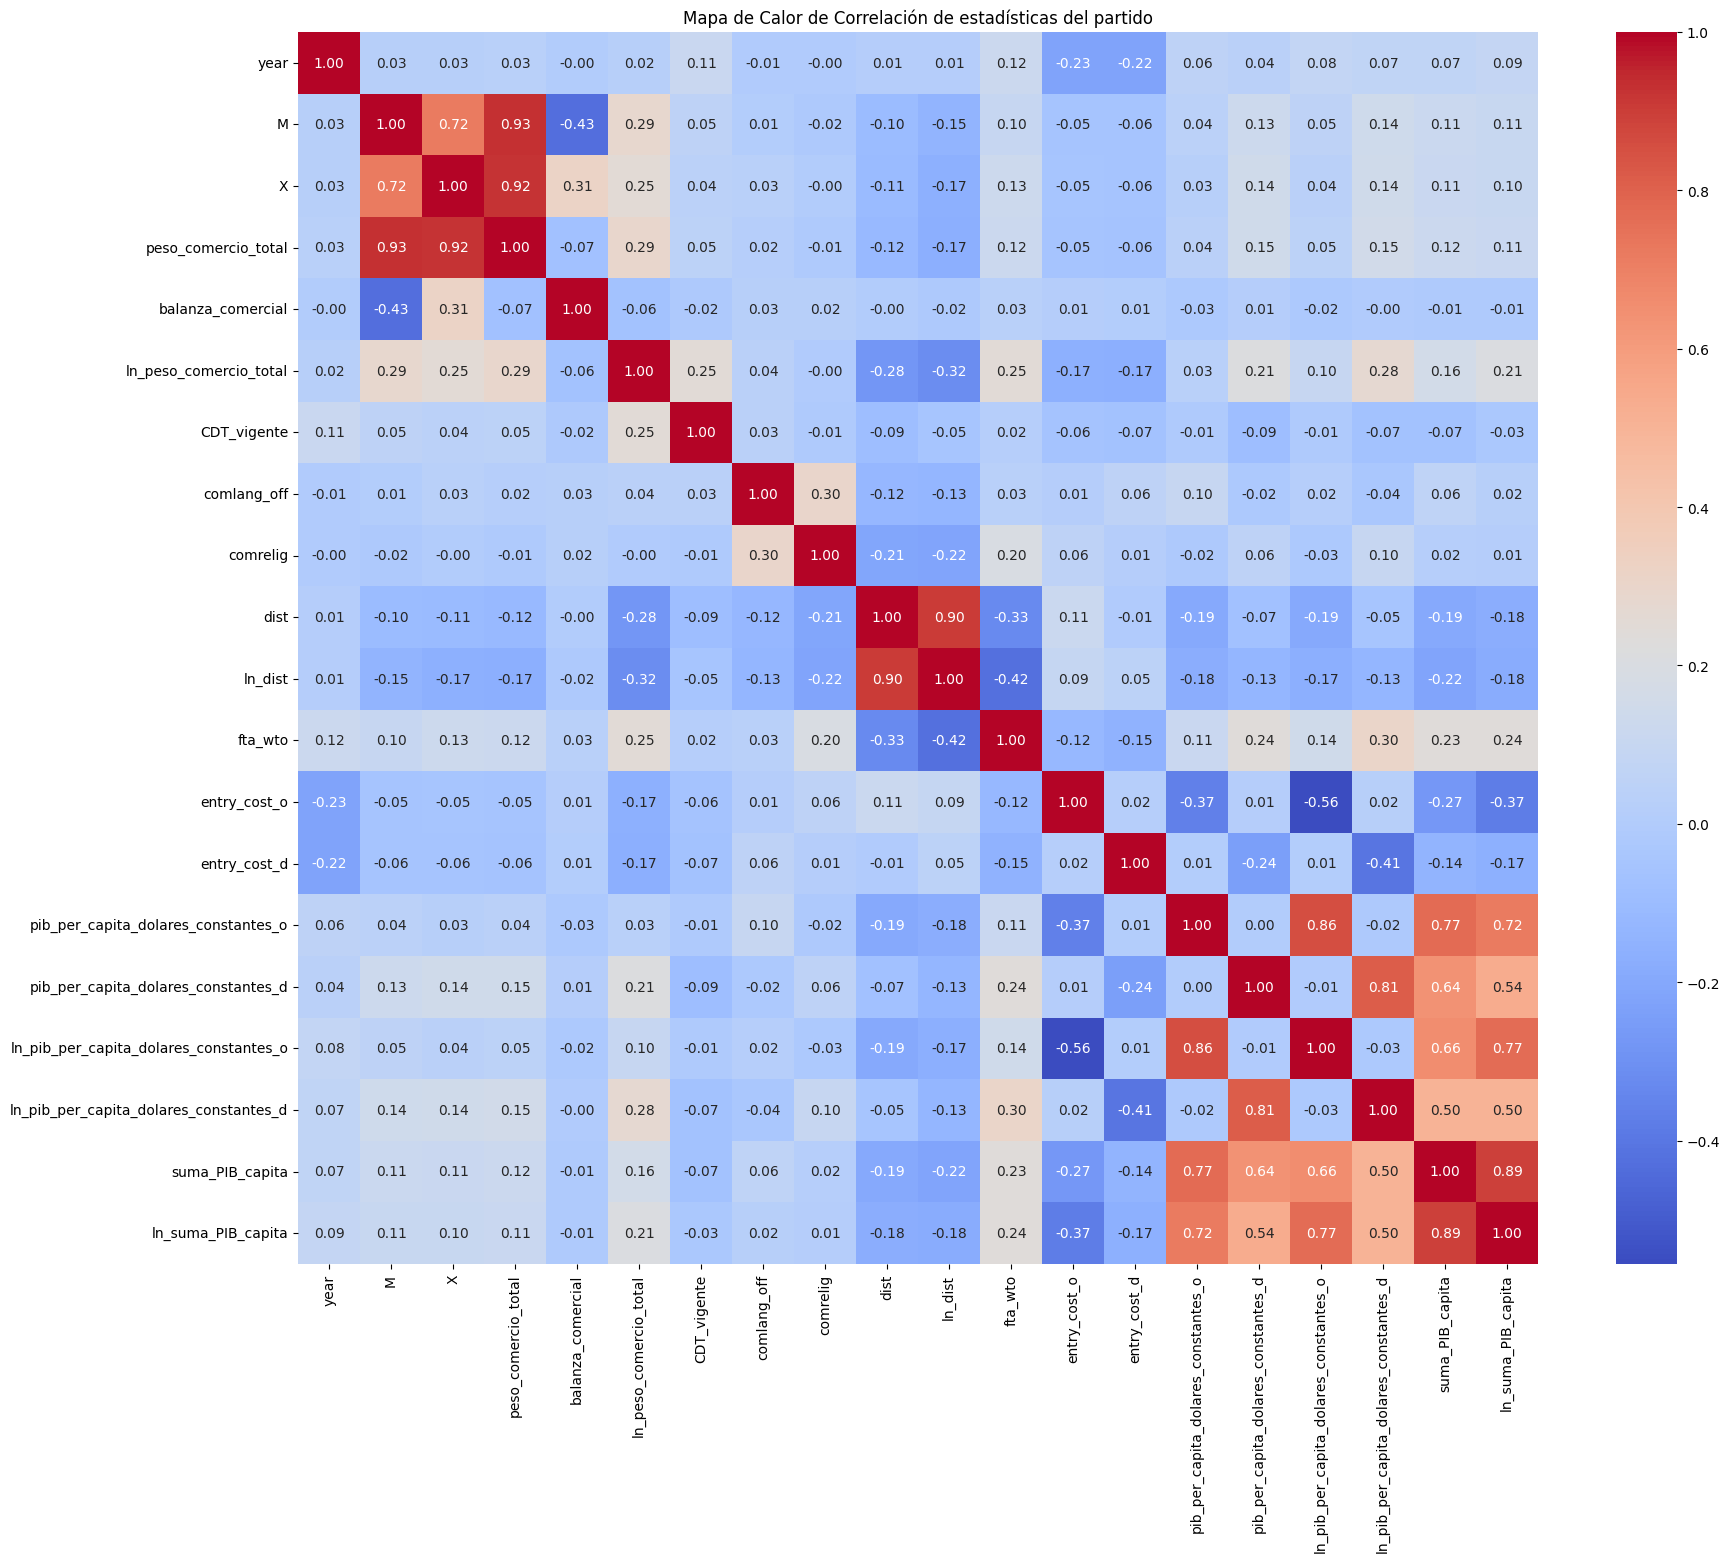

In [54]:
import seaborn as sns
from scipy import stats
baseERGM_VERGM_normalizadas_num=base_para_R.select_dtypes(include=['float64', 'int64'])
matriz_correlacion = baseERGM_VERGM_normalizadas_num.corr()

# Crear el mapa de calor
plt.figure(figsize=(20,16))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Calor de Correlación de estadísticas del partido')
plt.show()

In [55]:
base_para_R['ln_peso_comercio_total'].describe()

,ln_peso_comercio_total
count,114569.00
mean,16.42
std,4.23
min,0.01
25%,13.74
50%,16.87
75%,19.55
max,26.68


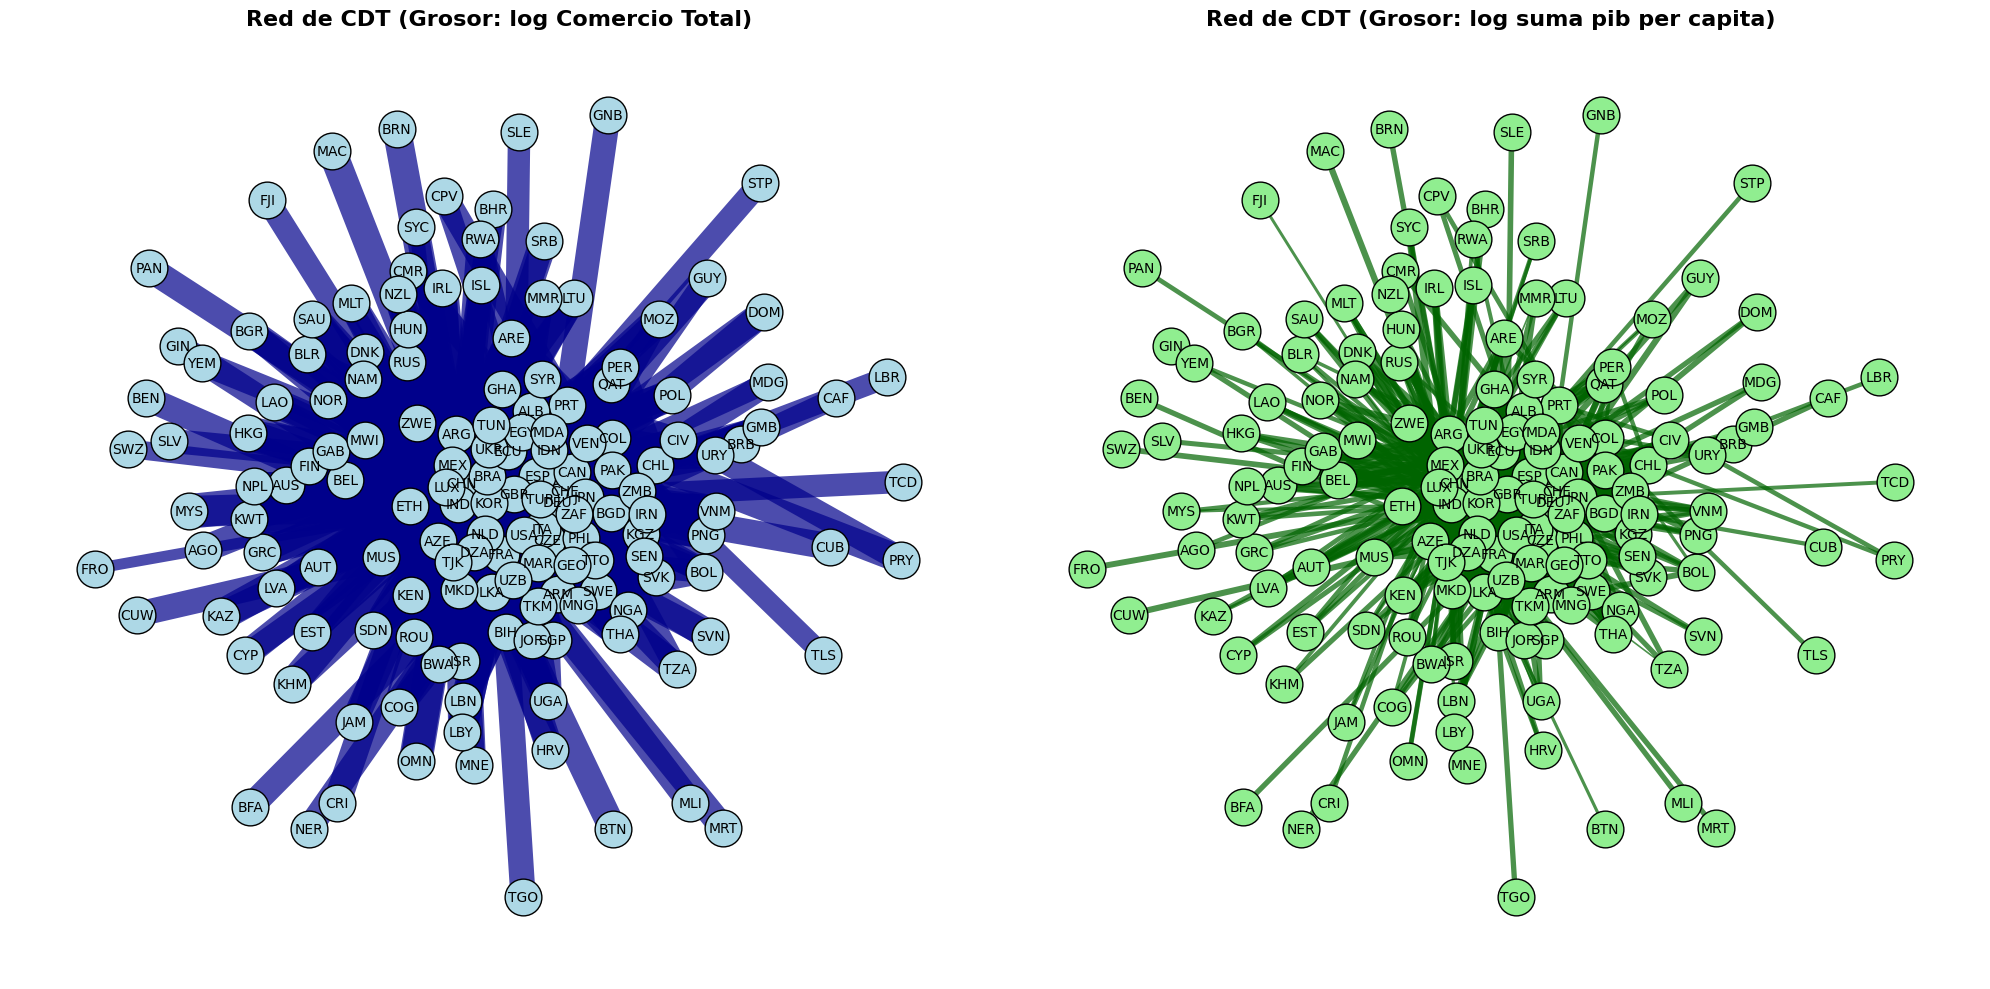

In [56]:
df_red = base_para_R[(base_para_R['year'] == 2024) & (base_para_R['CDT_vigente'] == 1)].copy()
G1 = nx.from_pandas_edgelist(df_red, source='iso3_o', target='iso3_d', edge_attr='ln_peso_comercio_total')
G2 = nx.from_pandas_edgelist(df_red, source='iso3_o', target='iso3_d', edge_attr='ln_suma_PIB_capita')

posiciones = nx.spring_layout(G1, seed=2026, k=0.5)
pesos_g1 = [d['ln_peso_comercio_total'] for (u, v, d) in G1.edges(data=True)]
pesos_g2_crudos = [d['ln_suma_PIB_capita'] for (u, v, d) in G2.edges(data=True)]
min_w = min(pesos_g2_crudos)
max_w = max(pesos_g2_crudos)
pesos_g2 = [(((w - min_w) / (max_w - min_w)) * 4) + 1 for w in pesos_g2_crudos]


fig, axes = plt.subplots(1, 2, figsize=(20, 10))


nx.draw_networkx_nodes(G1, posiciones, ax=axes[0], node_color='lightblue', node_size=700, edgecolors='black')
nx.draw_networkx_edges(G1, posiciones, ax=axes[0], width=pesos_g1, edge_color='darkblue', alpha=0.7)
nx.draw_networkx_labels(G1, posiciones, ax=axes[0], font_size=10, font_family='sans-serif')
axes[0].set_title('Red de CDT (Grosor: log Comercio Total)', fontsize=16, fontweight='bold')
axes[0].axis('off')


nx.draw_networkx_nodes(G2, posiciones, ax=axes[1], node_color='lightgreen', node_size=700, edgecolors='black')
nx.draw_networkx_edges(G2, posiciones, ax=axes[1], width=pesos_g2, edge_color='darkgreen', alpha=0.7)
nx.draw_networkx_labels(G2, posiciones, ax=axes[1], font_size=10, font_family='sans-serif')
axes[1].set_title('Red de CDT (Grosor: log suma pib per capita)', fontsize=16, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()